# NEPSE Stock Market Price Prediction
### Five Companies: NABIL (Banking), UPPER (Hydropower), SANIMA (Banking), NLIC (Insurance), CHCL (Manufacturing/Finance)
---

## Part 1: Data Collection and Preprocessing

In [1]:
# Install required libraries (run once if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet mplfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


### 1.1 Load Data

In [3]:
nabil  = pd.read_csv("Data/NABIL.csv")
upper  = pd.read_csv("Data/UPPER.csv")
sanima = pd.read_csv("Data/SANIMA.csv")
nlic   = pd.read_csv("Data/NLIC.csv")
chcl   = pd.read_csv("Data/CHCL.csv")

stocks = {'NABIL': nabil, 'UPPER': upper, 'SANIMA': sanima, 'NLIC': nlic, 'CHCL': chcl}
sectors = {'NABIL': 'Banking', 'UPPER': 'Hydropower', 'SANIMA': 'Banking', 'NLIC': 'Insurance', 'CHCL': 'Finance/Mfg'}

print('Data loaded successfully!')
for name, df in stocks.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

Data loaded successfully!
NABIL: 3417 rows, 9 columns
UPPER: 1617 rows, 9 columns
SANIMA: 3217 rows, 9 columns
NLIC: 3267 rows, 9 columns
CHCL: 4367 rows, 9 columns


### 1.2 Data Cleaning & Preprocessing

In [4]:
def preprocess(df, name):
    df = df.copy()
    # Rename columns to standard names
    df.columns = df.columns.str.lower().str.strip()
    rename_map = {
        'published_date': 'date',
        'traded_quantity': 'volume',
        'traded_amount': 'turnover',
        'per_change': 'pct_change'
    }
    df.rename(columns=rename_map, inplace=True)

    # Parse date
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Drop 'status' column if exists
    if 'status' in df.columns:
        df.drop(columns=['status'], inplace=True)

    # Handle missing values
    before = df.isnull().sum().sum()
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
    after = df.isnull().sum().sum()
    print(f'{name}: {before} missing values filled, {after} remaining')

    # Add company column
    df['company'] = name
    return df

for name in stocks:
    stocks[name] = preprocess(stocks[name], name)

nabil, upper, sanima, nlic, chcl = stocks['NABIL'], stocks['UPPER'], stocks['SANIMA'], stocks['NLIC'], stocks['CHCL']
print('\nSample NABIL data:')
nabil.head()

NABIL: 1 missing values filled, 0 remaining
UPPER: 0 missing values filled, 0 remaining
SANIMA: 1 missing values filled, 0 remaining
NLIC: 1 missing values filled, 0 remaining
CHCL: 1 missing values filled, 0 remaining

Sample NABIL data:


,date,open,high,low,close,pct_change,volume,turnover,company
0,2011-05-15,1091.0,1155.0,1112.0,1155.0,3.29,38.0,43057.0,NABIL
1,2011-05-16,1155.0,1193.0,1160.0,1193.0,3.29,156.0,183026.0,NABIL
2,2011-05-18,1193.0,1172.0,1150.0,1172.0,-1.76,939.0,1087972.0,NABIL
3,2011-05-19,1172.0,1194.0,1155.0,1194.0,1.88,490.0,573992.0,NABIL
4,2011-05-22,1194.0,1193.0,1178.0,1178.0,-1.34,115.0,135930.0,NABIL


In [5]:
# Check data info
print(nabil.info())
print('\nDate range for each company:')
for name, df in stocks.items():
    print(f'{name}: {df.date.min().date()} to {df.date.max().date()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        3417 non-null   datetime64[ns]
 1   open        3417 non-null   float64       
 2   high        3417 non-null   float64       
 3   low         3417 non-null   float64       
 4   close       3417 non-null   float64       
 5   pct_change  3417 non-null   float64       
 6   volume      3417 non-null   float64       
 7   turnover    3417 non-null   float64       
 8   company     3417 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 240.4+ KB
None

Date range for each company:
NABIL: 2011-05-15 to 2026-04-30
UPPER: 2019-03-19 to 2026-04-30
SANIMA: 2012-04-12 to 2026-04-30
NLIC: 2011-03-29 to 2026-04-30
CHCL: 2006-06-13 to 2026-04-30


### 1.3 Data Exploration – Summary Statistics

In [6]:
for name, df in stocks.items():
    print(f'\n===== {name} ({sectors[name]}) =====')
    print(df[['open','high','low','close','volume']].describe().round(2))


===== NABIL (Banking) =====
          open     high      low    close     volume
count  3417.00  3417.00  3417.00  3417.00    3417.00
mean   1216.11  1229.03  1201.09  1214.95   35026.51
std     594.57   602.57   588.74   596.46   53856.93
min     421.10   425.00   419.00   422.00      24.00
25%     749.00   754.00   739.00   744.00    2874.00
50%    1051.00  1060.00  1031.00  1047.00    9623.00
75%    1700.00  1718.00  1682.00  1700.00   50106.00
max    2720.00  2800.00  2700.00  2750.00  705430.00

===== UPPER (Hydropower) =====
          open     high      low    close      volume
count  1617.00  1617.00  1617.00  1617.00     1617.00
mean    355.55   362.36   348.02   353.84   147177.03
std     192.19   196.98   186.38   190.44   234917.13
min     152.50   154.90   152.10   153.10       30.00
25%     207.10   210.00   203.00   206.10    35952.00
50%     247.00   253.00   243.00   246.00    78771.00
75%     483.40   491.00   473.20   479.00   160123.00
max     930.00   962.50   893.

In [7]:
# Summary table: mean closing price
summary = pd.DataFrame({
    'Company': list(stocks.keys()),
    'Sector': [sectors[n] for n in stocks],
    'Mean Close': [df['close'].mean() for df in stocks.values()],
    'Std Close':  [df['close'].std()  for df in stocks.values()],
    'Min Close':  [df['close'].min()  for df in stocks.values()],
    'Max Close':  [df['close'].max()  for df in stocks.values()],
    'Total Records': [len(df) for df in stocks.values()]
}).round(2)
summary

,Company,Sector,Mean Close,Std Close,Min Close,Max Close,Total Records
0,NABIL,Banking,1214.95,596.46,422.0,2750.0,3417
1,UPPER,Hydropower,353.84,190.44,153.1,908.0,1617
2,SANIMA,Banking,386.27,149.95,160.0,929.0,3217
3,NLIC,Insurance,1734.63,1196.93,525.0,5670.0,3267
4,CHCL,Finance/Mfg,883.34,441.01,281.0,2742.0,4367


## Part 2: Exploratory Data Analysis (EDA)

### 2.1 Closing Price Line Charts

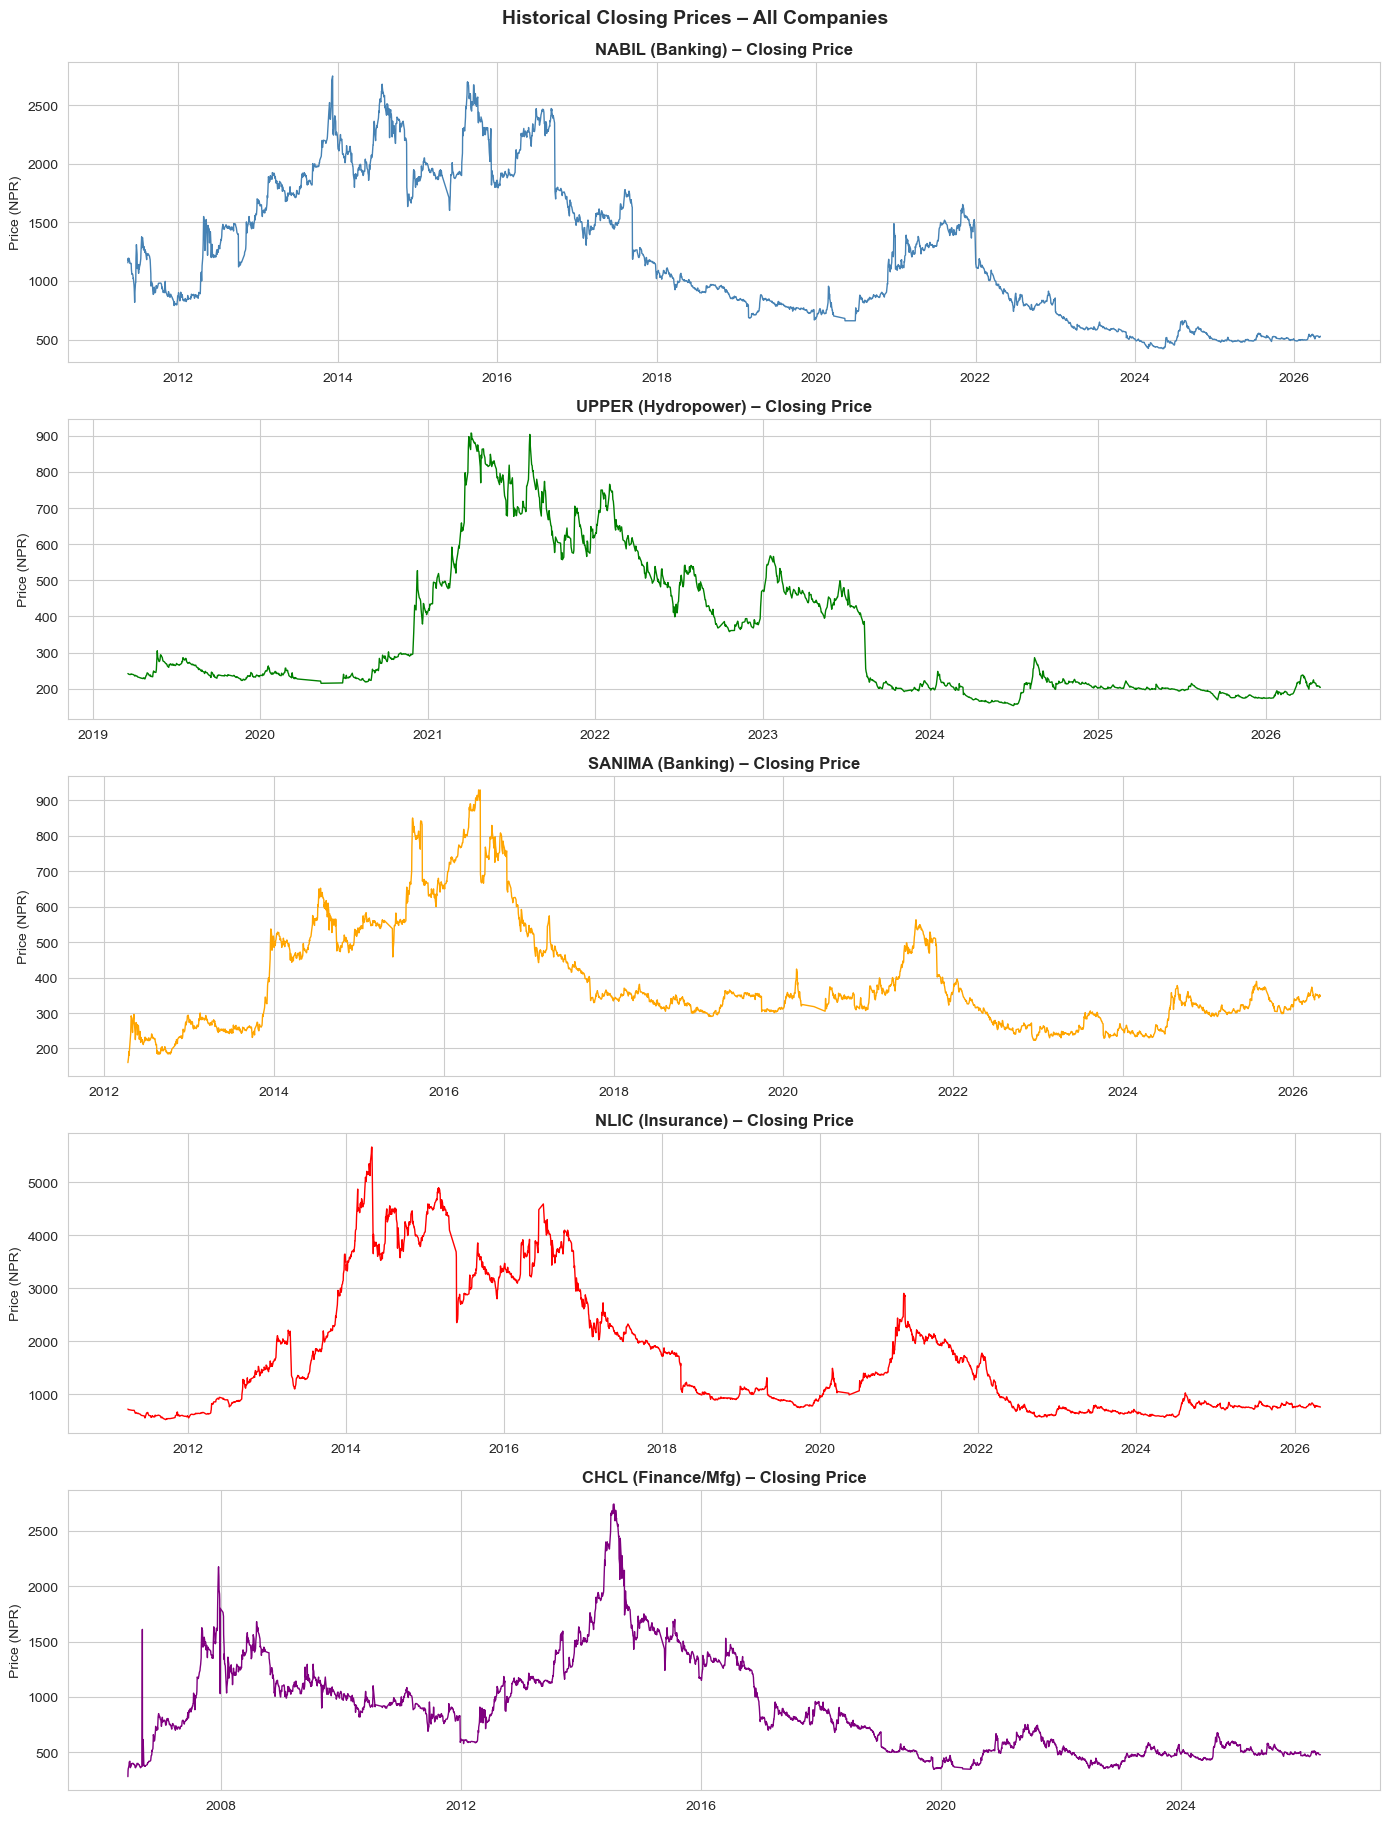

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
colors = ['steelblue', 'green', 'orange', 'red', 'purple']

for ax, (name, df), color in zip(axes, stocks.items(), colors):
    ax.plot(df['date'], df['close'], color=color, linewidth=1)
    ax.set_title(f'{name} ({sectors[name]}) – Closing Price', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (NPR)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.suptitle('Historical Closing Prices – All Companies', fontsize=14, fontweight='bold', y=1.01)
plt.show()

### 2.2 Volume Traded Trends

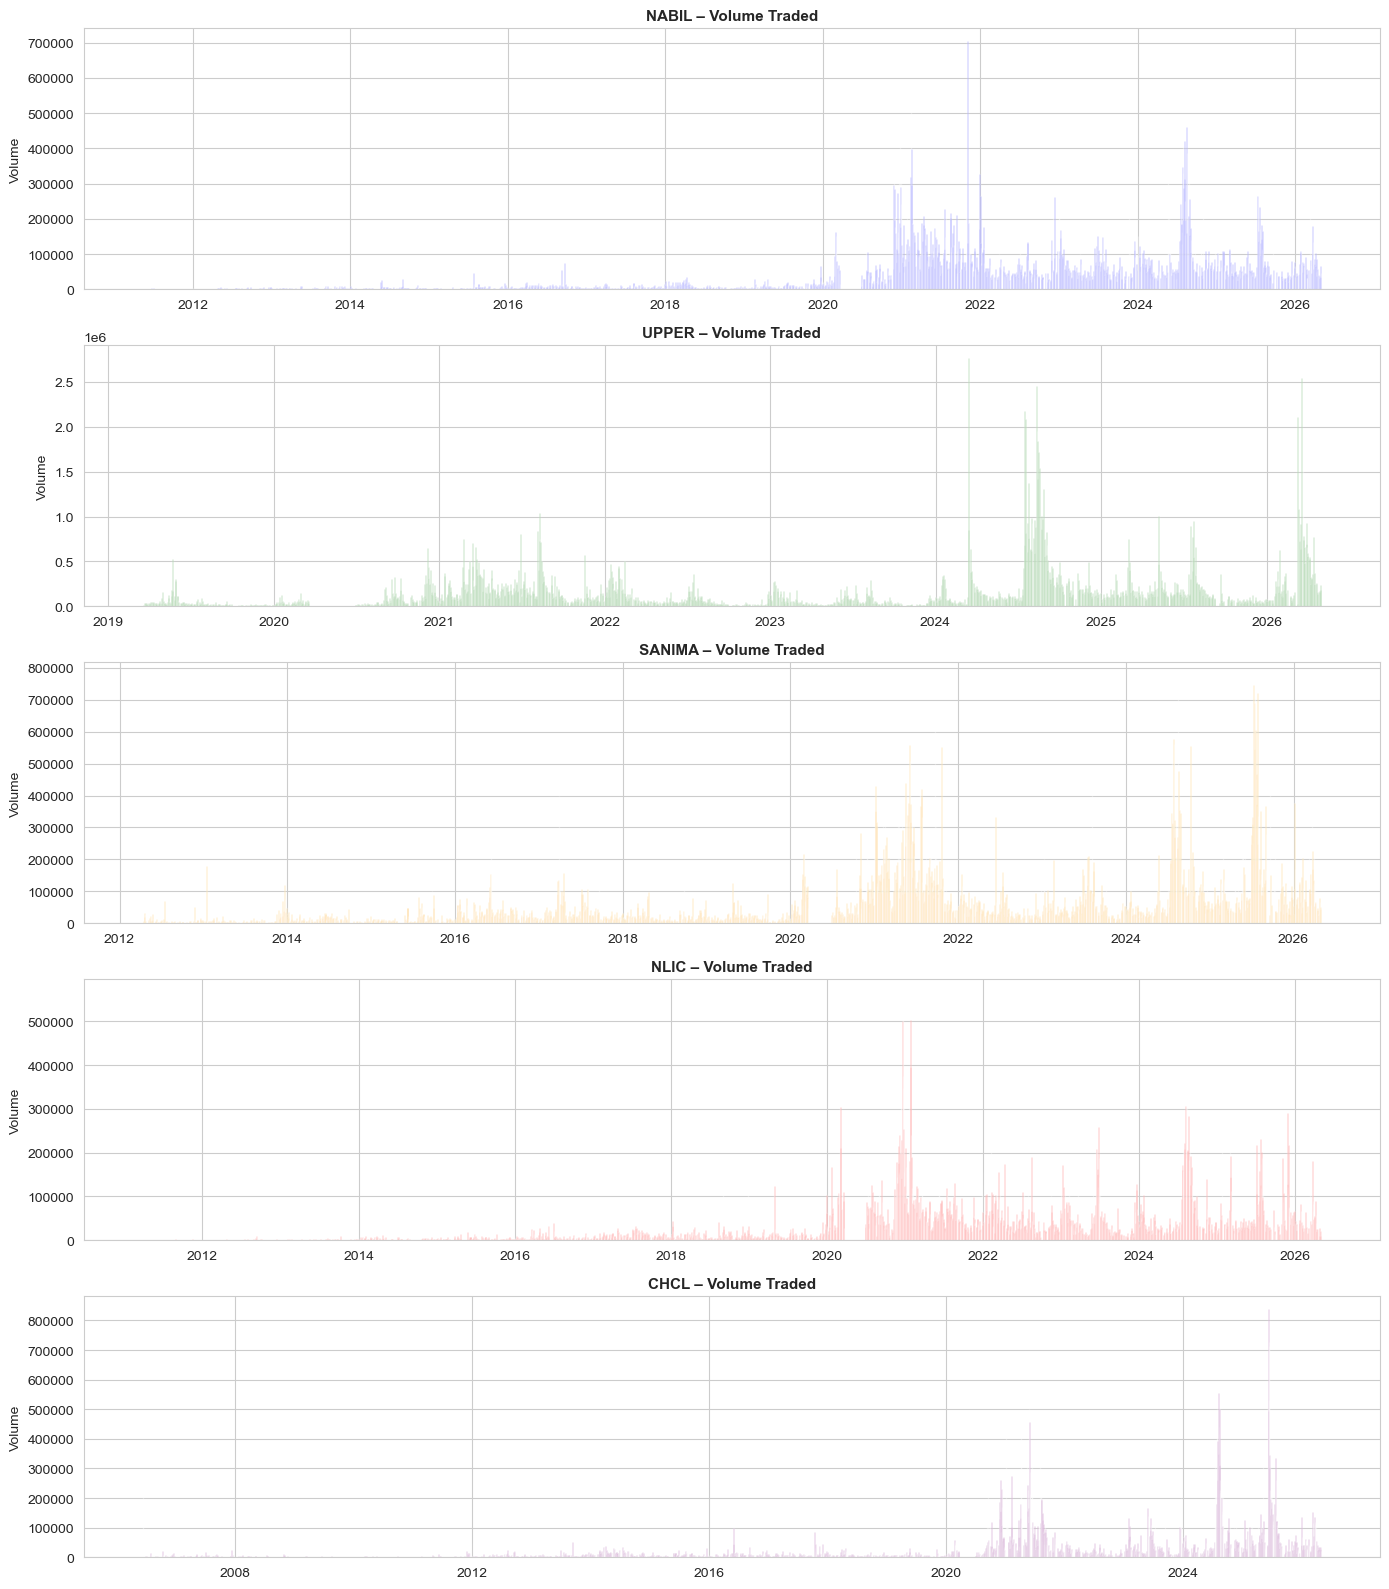

In [32]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16))
colors = ['blue', 'green', 'orange', 'red', 'purple']

for ax, (name, df), color in zip(axes, stocks.items(), colors):
    ax.bar(df['date'], df['volume'], color=color, alpha=0.3, width=2)
    ax.set_title(f'{name} – Volume Traded', fontsize=11, fontweight='bold')
    ax.set_ylabel('Volume')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 2.3 Correlation Heatmaps

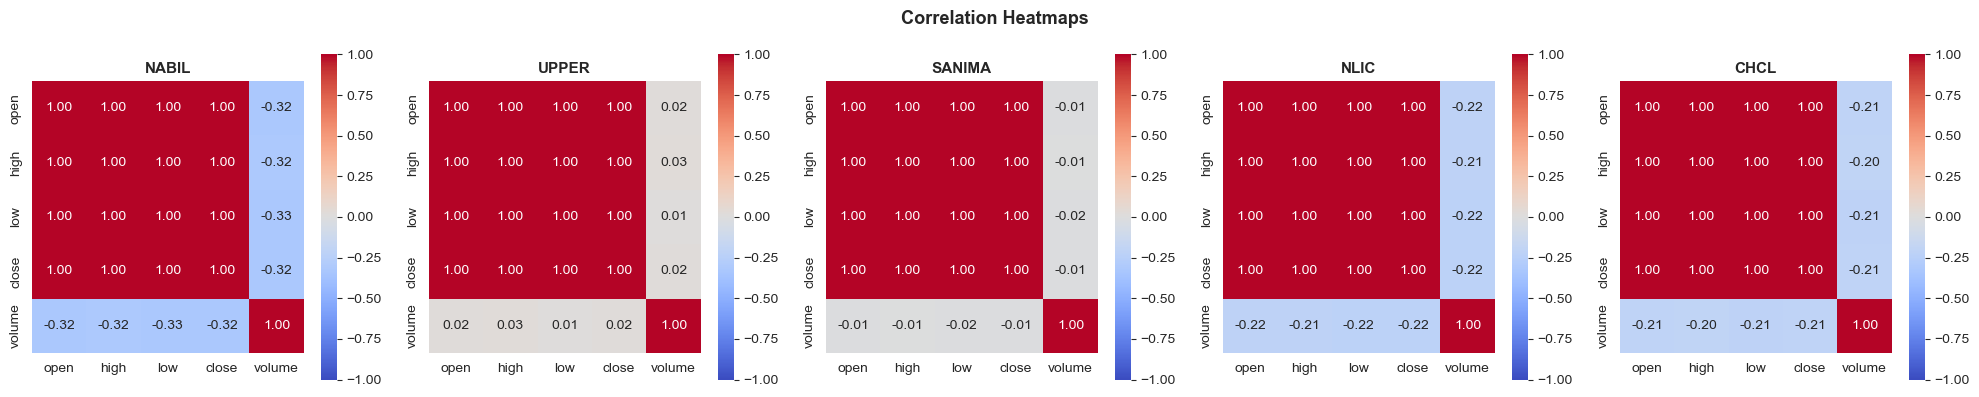

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, df) in zip(axes, stocks.items()):
    corr = df[['open','high','low','close','volume']].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Correlation Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Comparison – All Companies Closing Price (Normalized)

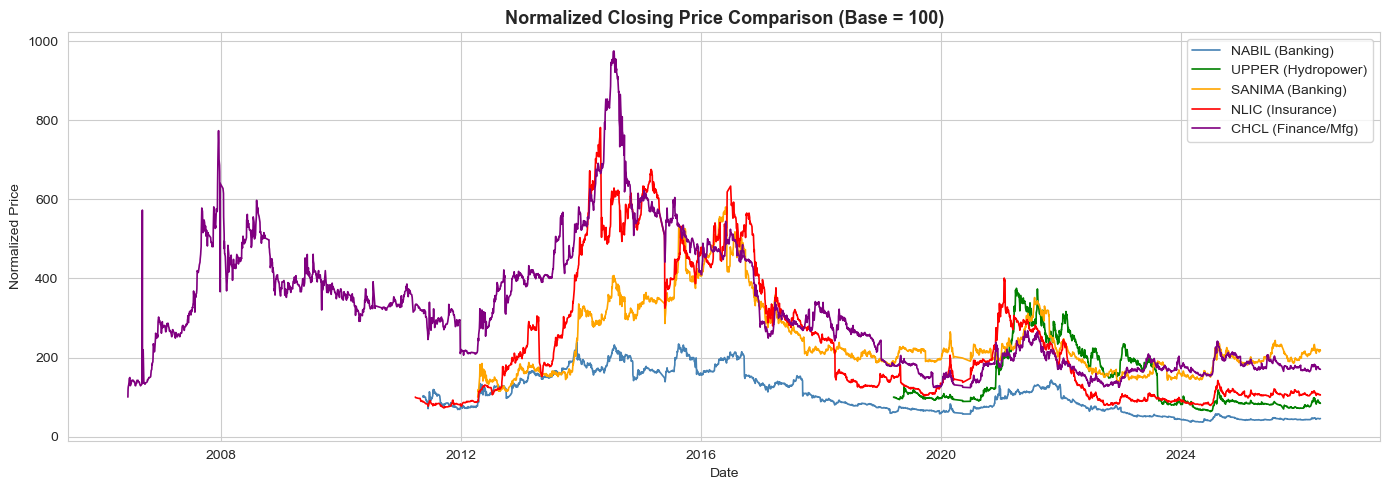

In [11]:
plt.figure(figsize=(14, 5))
colors = ['steelblue', 'green', 'orange', 'red', 'purple']

for (name, df), color in zip(stocks.items(), colors):
    # Normalize to 100 base
    norm = (df['close'] / df['close'].iloc[0]) * 100
    plt.plot(df['date'], norm, label=f'{name} ({sectors[name]})', color=color, linewidth=1.2)

plt.title('Normalized Closing Price Comparison (Base = 100)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 Trend Analysis – Moving Averages (Bullish/Bearish)

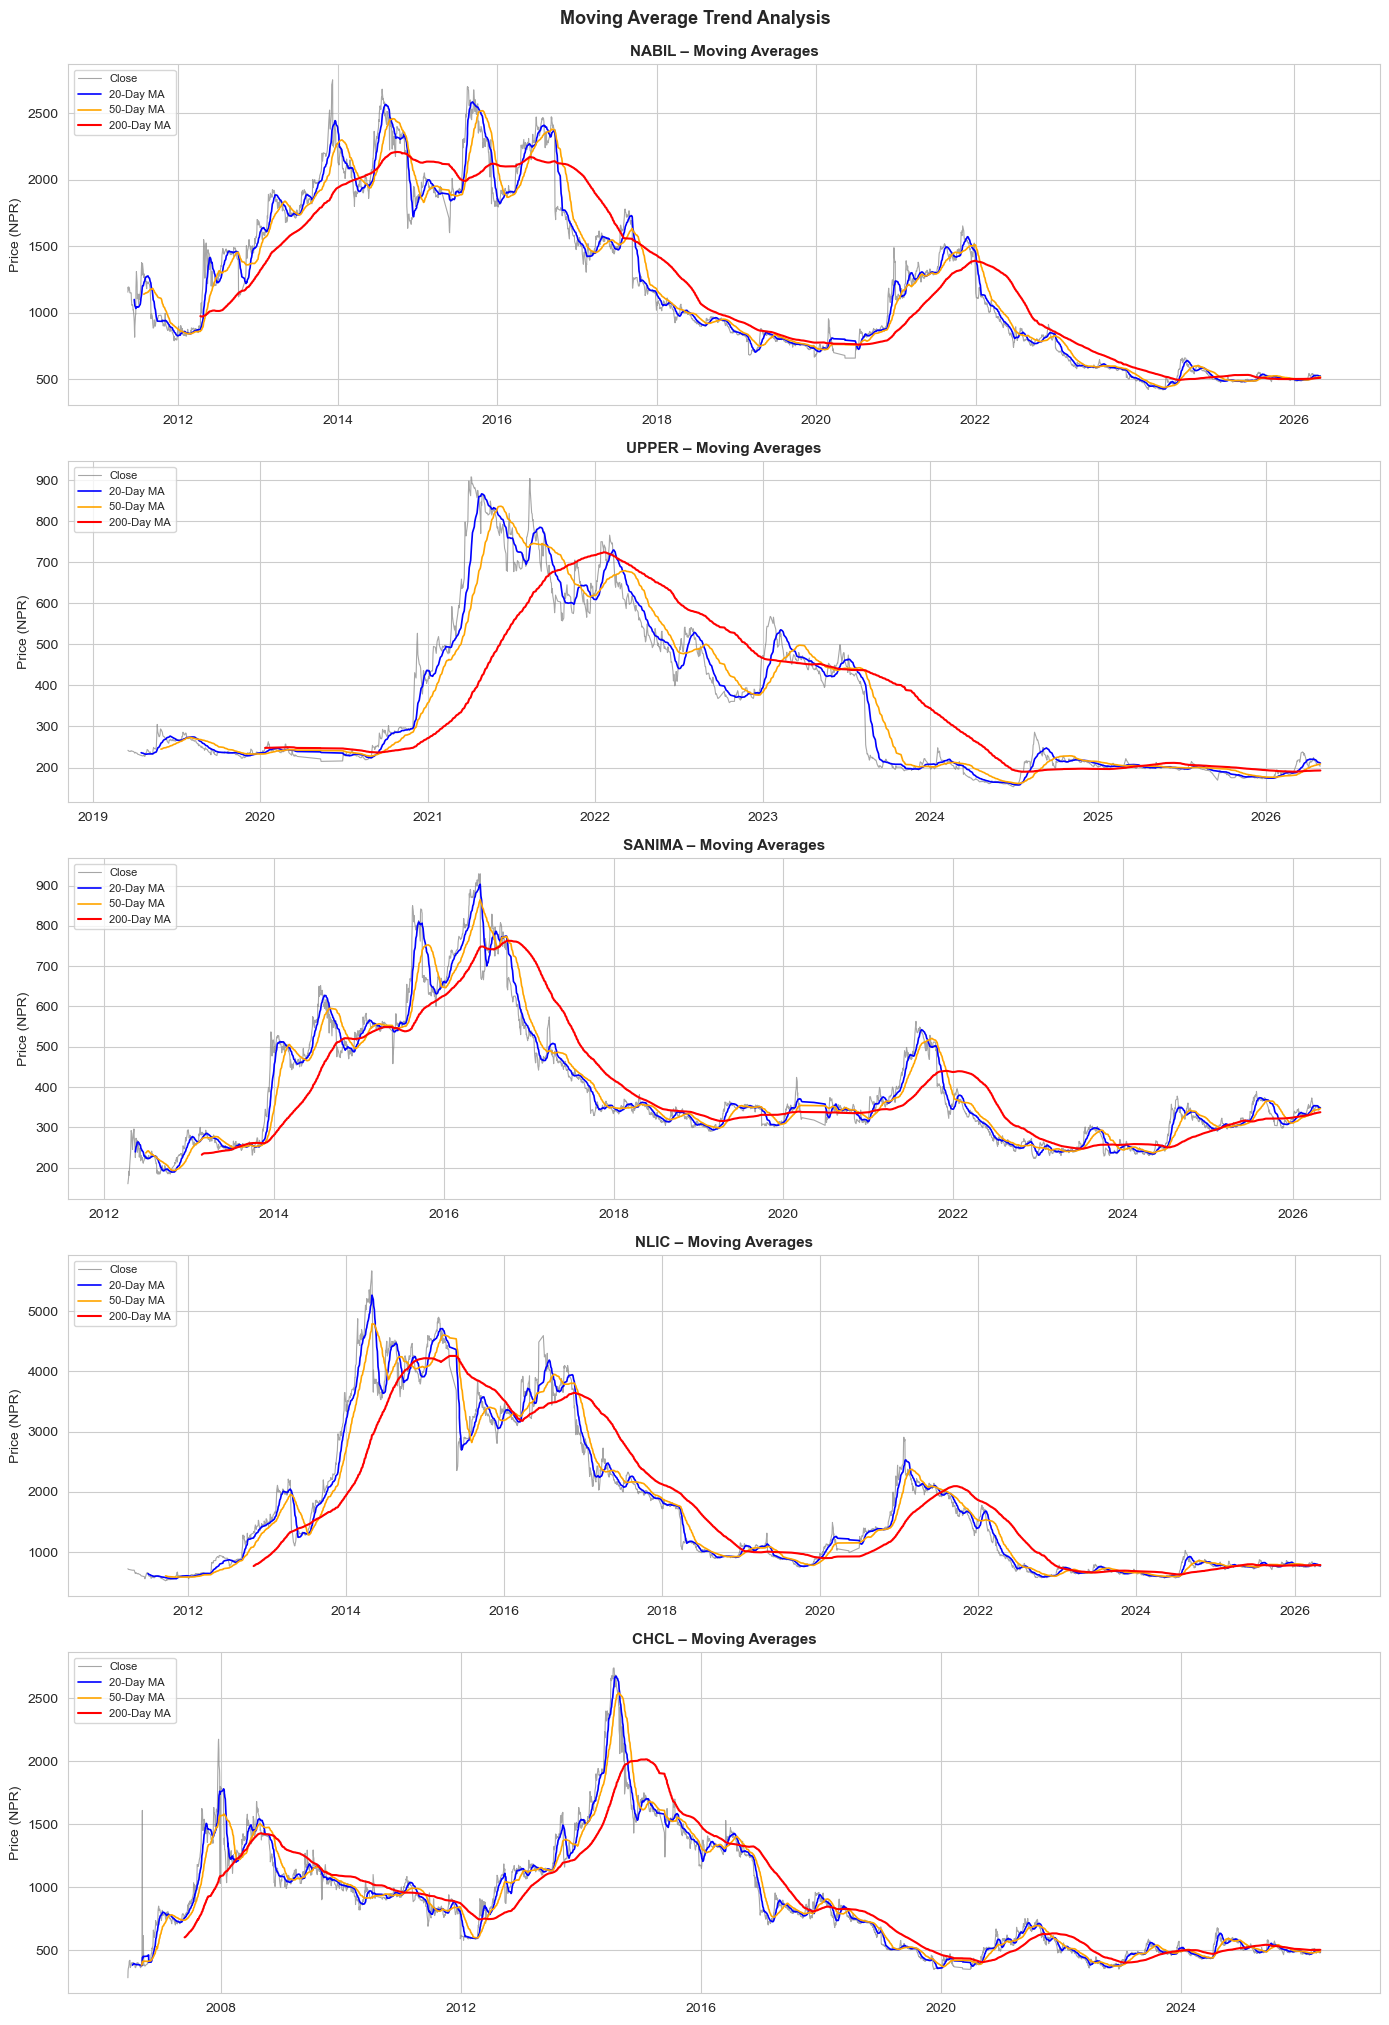

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for ax, (name, df) in zip(axes, stocks.items()):
    df = df.copy()
    df['MA20']  = df['close'].rolling(window=20).mean()
    df['MA50']  = df['close'].rolling(window=50).mean()
    df['MA200'] = df['close'].rolling(window=200).mean()

    ax.plot(df['date'], df['close'], label='Close', color='gray', linewidth=0.8, alpha=0.7)
    ax.plot(df['date'], df['MA20'],  label='20-Day MA', color='blue',   linewidth=1.2)
    ax.plot(df['date'], df['MA50'],  label='50-Day MA', color='orange', linewidth=1.2)
    ax.plot(df['date'], df['MA200'], label='200-Day MA', color='red',   linewidth=1.5)
    ax.set_title(f'{name} – Moving Averages', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (NPR)')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.suptitle('Moving Average Trend Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.show()

### 2.6 Volatility Analysis – Bollinger Bands

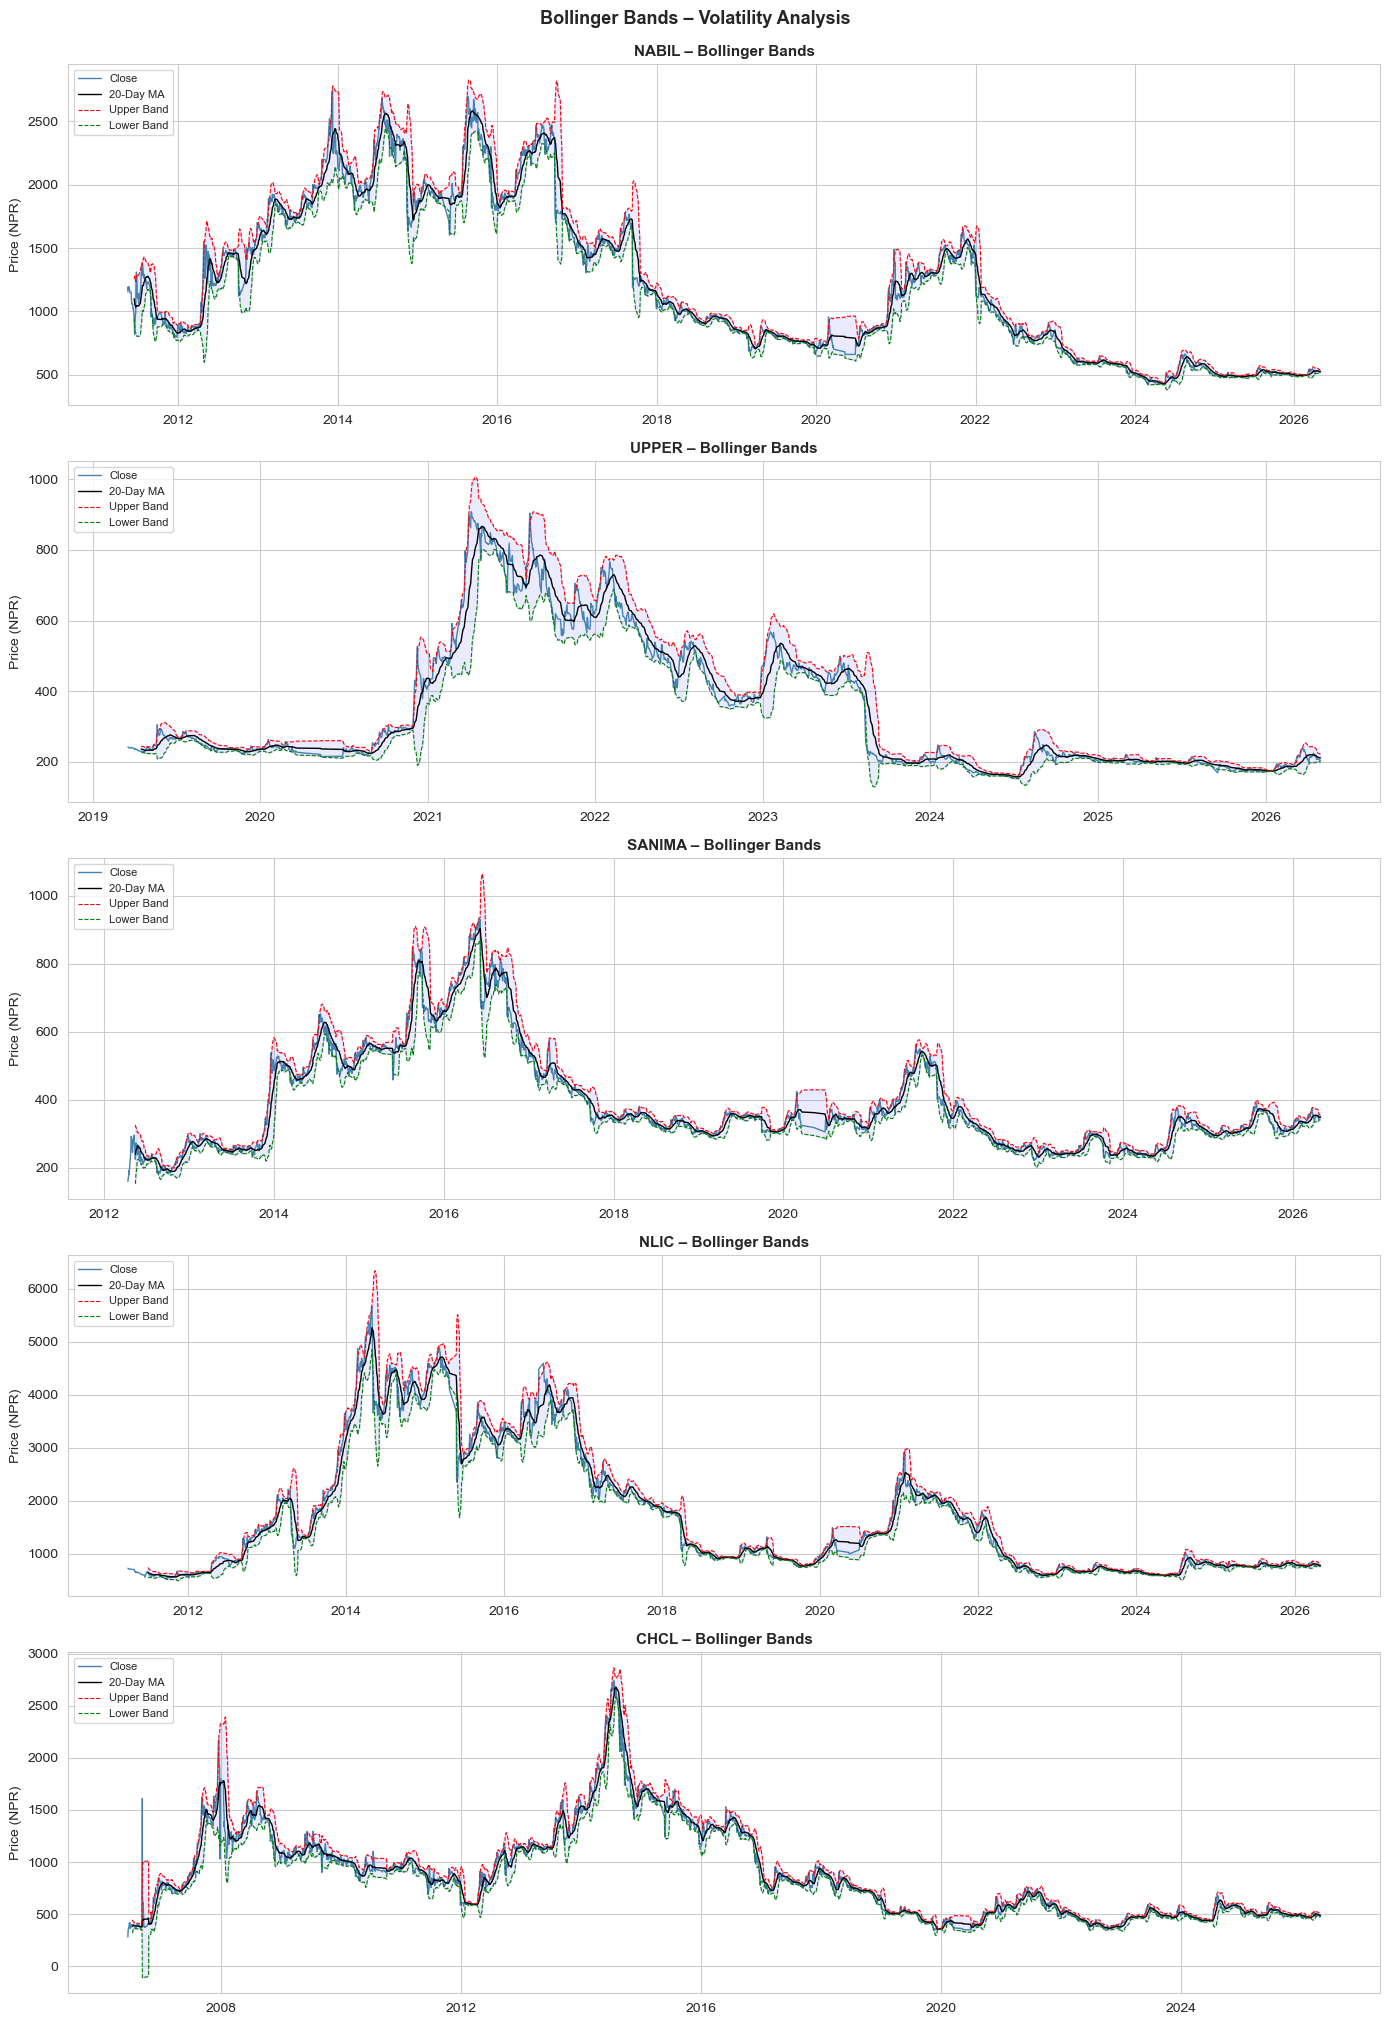

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for ax, (name, df) in zip(axes, stocks.items()):
    df = df.copy()
    df['MA20'] = df['close'].rolling(20).mean()
    df['STD20'] = df['close'].rolling(20).std()
    df['Upper_BB'] = df['MA20'] + 2 * df['STD20']
    df['Lower_BB'] = df['MA20'] - 2 * df['STD20']

    ax.plot(df['date'], df['close'],    label='Close',      color='steelblue', linewidth=1)
    ax.plot(df['date'], df['MA20'],     label='20-Day MA',  color='black',     linewidth=1)
    ax.plot(df['date'], df['Upper_BB'], label='Upper Band', color='red',       linewidth=0.8, linestyle='--')
    ax.plot(df['date'], df['Lower_BB'], label='Lower Band', color='green',     linewidth=0.8, linestyle='--')
    ax.fill_between(df['date'], df['Upper_BB'], df['Lower_BB'], alpha=0.08, color='blue')
    ax.set_title(f'{name} – Bollinger Bands', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (NPR)')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.suptitle('Bollinger Bands – Volatility Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.show()

### 2.7 Volatility Comparison (Standard Deviation of Daily Returns)

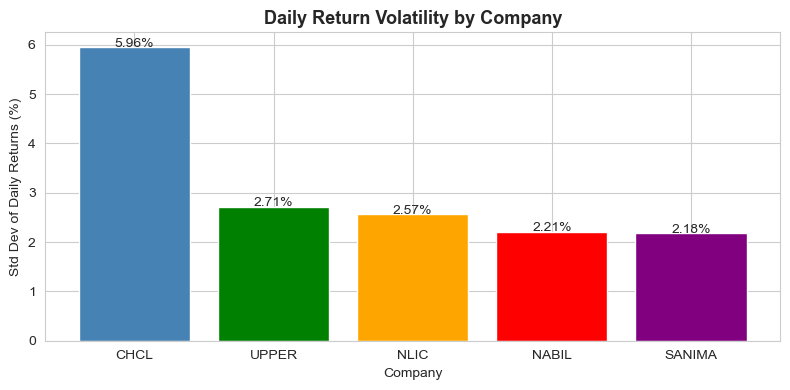

Company  Volatility (%)      Sector
   CHCL        5.955545 Finance/Mfg
  UPPER        2.714283  Hydropower
   NLIC        2.568751   Insurance
  NABIL        2.213479     Banking
 SANIMA        2.177071     Banking


In [14]:
vol_data = {}
for name, df in stocks.items():
    daily_returns = df['close'].pct_change().dropna()
    vol_data[name] = daily_returns.std() * 100  # in %

vol_df = pd.DataFrame({'Company': list(vol_data.keys()),
                       'Volatility (%)': list(vol_data.values()),
                       'Sector': [sectors[n] for n in vol_data]})
vol_df = vol_df.sort_values('Volatility (%)', ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(vol_df['Company'], vol_df['Volatility (%)'],
               color=['steelblue','green','orange','red','purple'])
plt.title('Daily Return Volatility by Company', fontsize=13, fontweight='bold')
plt.ylabel('Std Dev of Daily Returns (%)')
plt.xlabel('Company')
for bar, val in zip(bars, vol_df['Volatility (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(vol_df.to_string(index=False))

### 2.8 Sectoral Performance Analysis

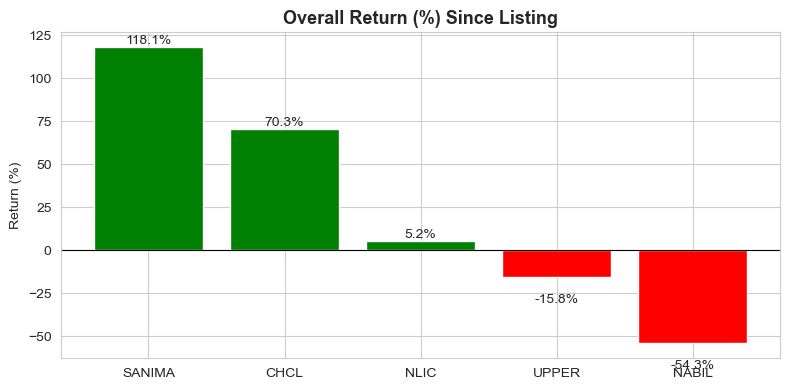

Company  Total Return (%)      Sector
 SANIMA        118.125000     Banking
   CHCL         70.284698 Finance/Mfg
   NLIC          5.227586   Insurance
  UPPER        -15.785124  Hydropower
  NABIL        -54.285714     Banking


In [15]:
# Compute overall return for each company
perf = {}
for name, df in stocks.items():
    start = df['close'].iloc[0]
    end   = df['close'].iloc[-1]
    perf[name] = ((end - start) / start) * 100

perf_df = pd.DataFrame({'Company': list(perf.keys()),
                        'Total Return (%)': list(perf.values()),
                        'Sector': [sectors[n] for n in perf]})
perf_df = perf_df.sort_values('Total Return (%)', ascending=False)

colors_bar = ['green' if v > 0 else 'red' for v in perf_df['Total Return (%)']]
plt.figure(figsize=(8, 4))
bars = plt.bar(perf_df['Company'], perf_df['Total Return (%)'], color=colors_bar)
plt.title('Overall Return (%) Since Listing', fontsize=13, fontweight='bold')
plt.ylabel('Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, perf_df['Total Return (%)']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (2 if val > 0 else -15),
             f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(perf_df.to_string(index=False))

### 2.9 Candlestick Chart (Recent 3 Months – NABIL Example)

mplfinance not installed. Run: pip install mplfinance
Showing OHLC line chart instead.


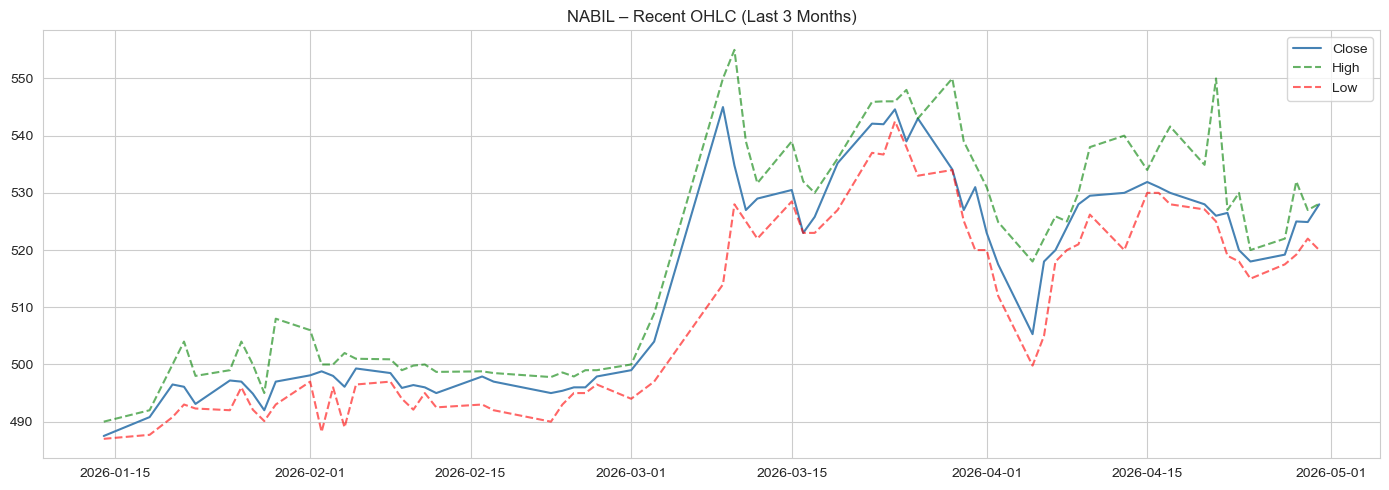

In [16]:
try:
    import mplfinance as mpf

    def plot_candlestick(df, name, months=3):
        df_c = df[['date','open','high','low','close','volume']].copy()
        df_c.set_index('date', inplace=True)
        df_c.index = pd.DatetimeIndex(df_c.index)
        recent = df_c.tail(months * 22)  # ~22 trading days/month
        mpf.plot(recent, type='candle', style='charles',
                 title=f'{name} – Candlestick (Last {months} Months)',
                 ylabel='Price (NPR)', volume=True, figsize=(14, 6))

    for name, df in stocks.items():
        plot_candlestick(df, name, months=3)

except ImportError:
    print("mplfinance not installed. Run: pip install mplfinance")
    print("Showing OHLC line chart instead.")
    fig, ax = plt.subplots(figsize=(14, 5))
    recent = nabil.tail(66)
    ax.plot(recent['date'], recent['close'], label='Close', color='steelblue')
    ax.plot(recent['date'], recent['high'],  label='High',  color='green', linestyle='--', alpha=0.6)
    ax.plot(recent['date'], recent['low'],   label='Low',   color='red',   linestyle='--', alpha=0.6)
    ax.set_title('NABIL – Recent OHLC (Last 3 Months)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Part 3: Predictive Modeling & Forecasting

### 3.1 Feature Engineering for ML Models

In [17]:
def prepare_features(df):
    df = df.copy()
    df['MA5']   = df['close'].rolling(5).mean()
    df['MA20']  = df['close'].rolling(20).mean()
    df['MA50']  = df['close'].rolling(50).mean()
    df['Return']= df['close'].pct_change()
    df['STD20'] = df['close'].rolling(20).std()
    df['HL_Gap']= df['high'] - df['low']
    df['OC_Gap']= df['close'] - df['open']
    df['Target']= df['close'].shift(-1)  # Next day's close
    df.dropna(inplace=True)
    return df

features = ['open','high','low','volume','MA5','MA20','MA50','Return','STD20','HL_Gap','OC_Gap']

results = {}

for name, raw_df in stocks.items():
    df = prepare_features(raw_df)
    X = df[features].values
    y = df['Target'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree':     DecisionTreeRegressor(max_depth=5, random_state=42),
        'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
    }

    results[name] = {}
    for mname, model in models.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)
        results[name][mname] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'preds': preds, 'actuals': y_test}

print('Model training complete!')

Model training complete!


### 3.2 Model Performance Metrics

In [18]:
rows = []
for company, models in results.items():
    for mname, metrics in models.items():
        rows.append({'Company': company, 'Model': mname,
                     'RMSE': round(metrics['RMSE'], 2),
                     'MAE':  round(metrics['MAE'],  2),
                     'R²':   round(metrics['R2'],   4)})

metrics_df = pd.DataFrame(rows)
metrics_df

,Company,Model,RMSE,MAE,R²
0,NABIL,Linear Regression,7.97,4.90,0.9762
1,NABIL,Decision Tree,97.84,85.88,-2.5882
2,NABIL,Random Forest,92.68,79.97,-2.2199
3,UPPER,Linear Regression,3.71,2.37,0.9248
4,UPPER,Decision Tree,9.44,7.19,0.5132
5,UPPER,Random Forest,5.86,4.58,0.8126
6,SANIMA,Linear Regression,5.51,3.72,0.9820
7,SANIMA,Decision Tree,8.45,6.80,0.9578
8,SANIMA,Random Forest,5.95,4.44,0.9790
9,NLIC,Linear Regression,13.75,9.65,0.9748


### 3.3 Actual vs Predicted Plots

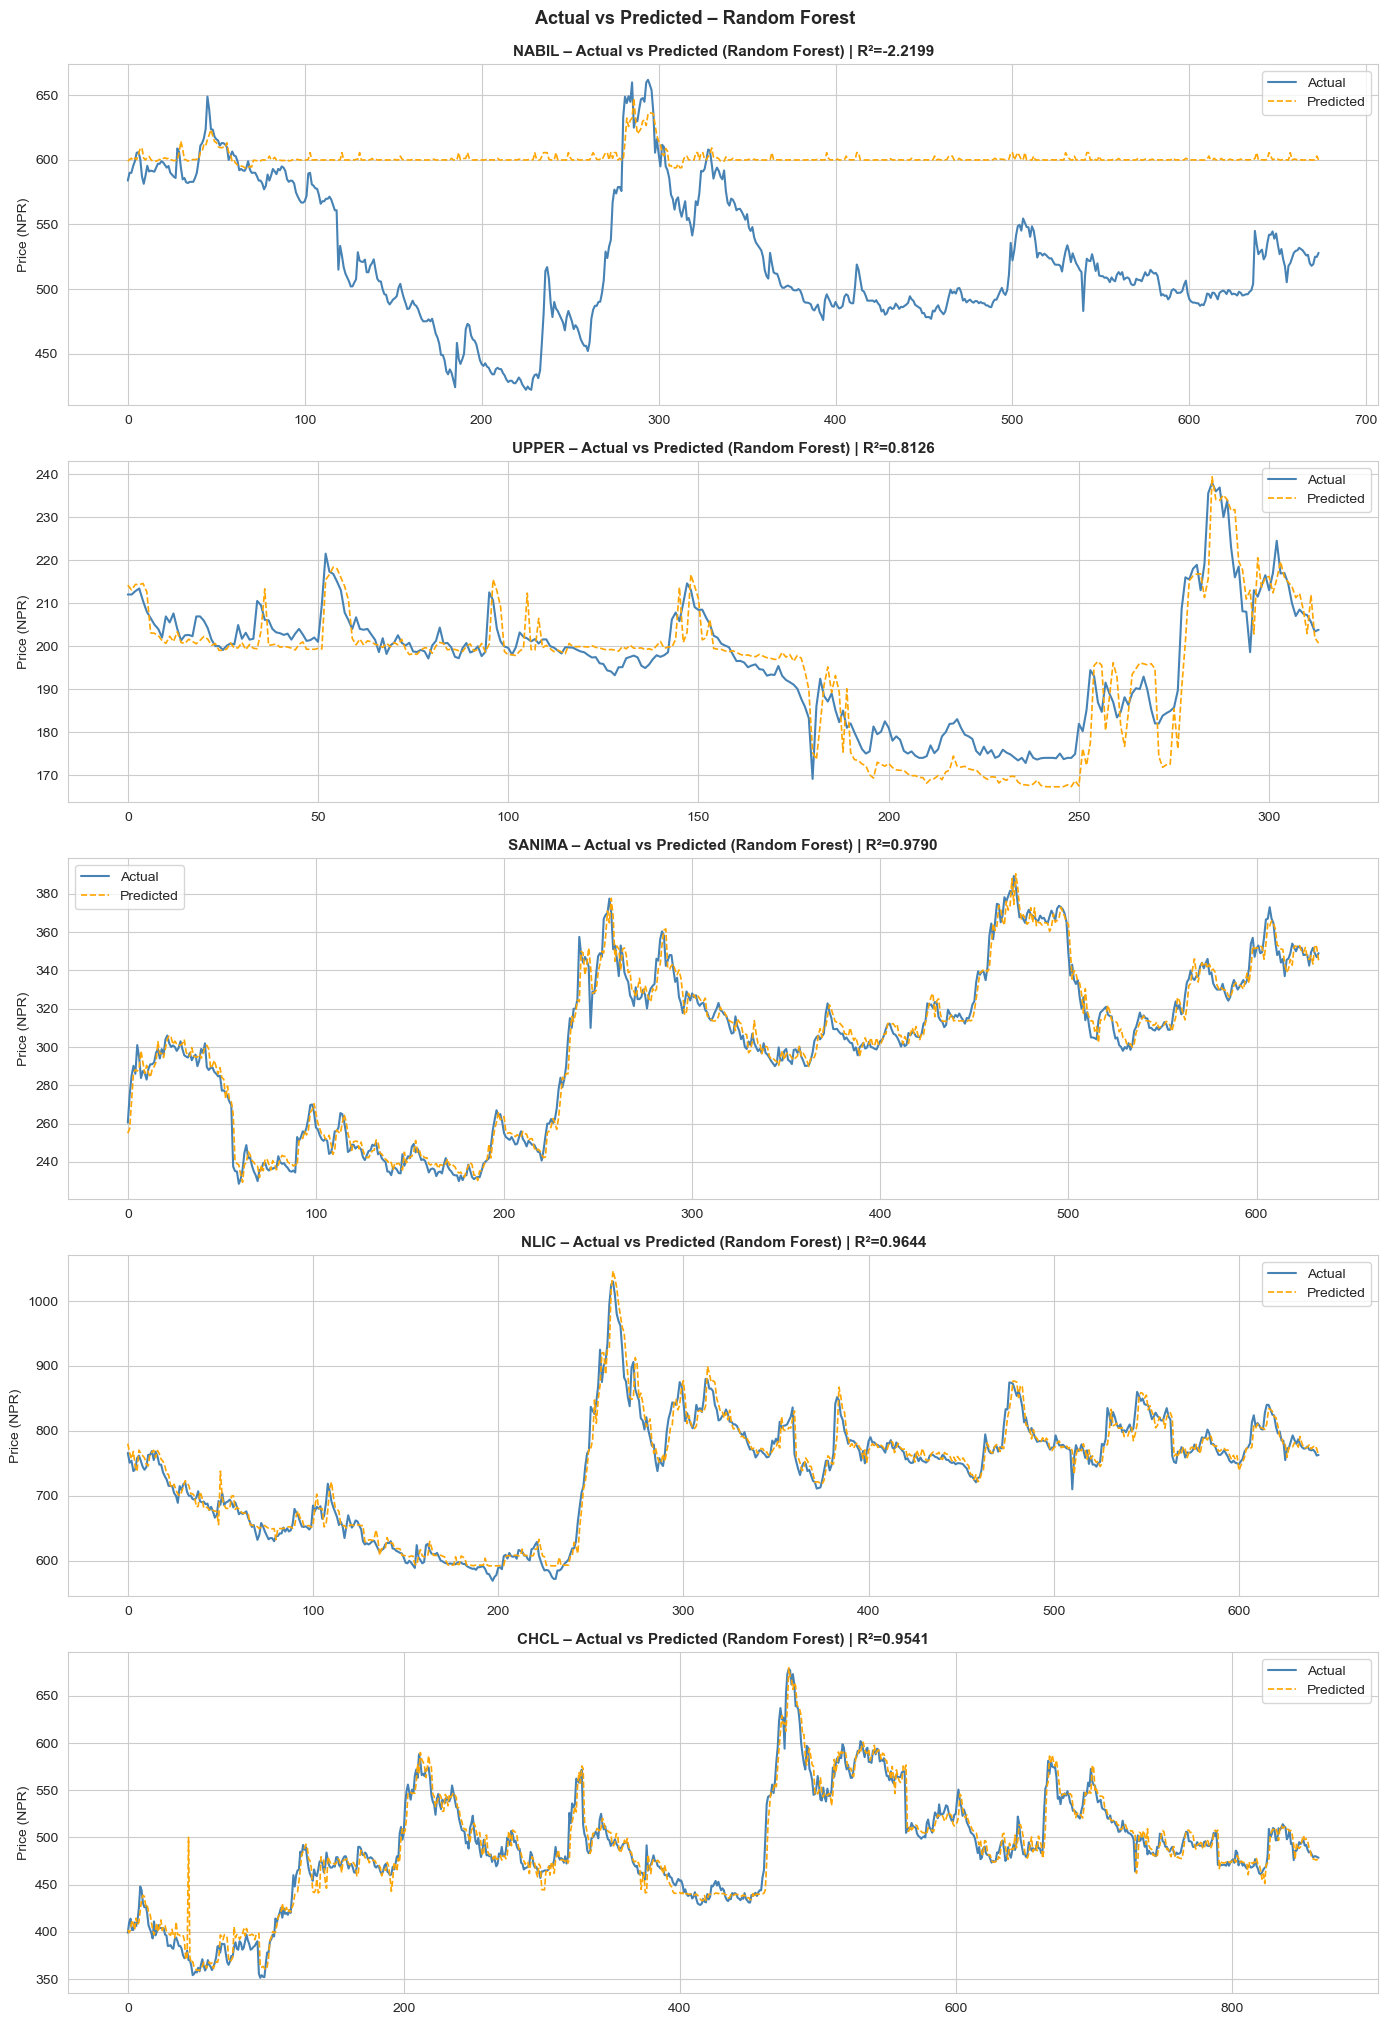

In [19]:
best_model = 'Random Forest'

fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for ax, (name, models) in zip(axes, results.items()):
    actuals = models[best_model]['actuals']
    preds   = models[best_model]['preds']
    ax.plot(actuals, label='Actual',    color='steelblue', linewidth=1.5)
    ax.plot(preds,   label='Predicted', color='orange',    linewidth=1.2, linestyle='--')
    r2 = models[best_model]['R2']
    ax.set_title(f'{name} – Actual vs Predicted (Random Forest) | R²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (NPR)')
    ax.legend()

plt.tight_layout()
plt.suptitle('Actual vs Predicted – Random Forest', fontsize=13, fontweight='bold', y=1.01)
plt.show()

### 3.4 R² Comparison Bar Chart

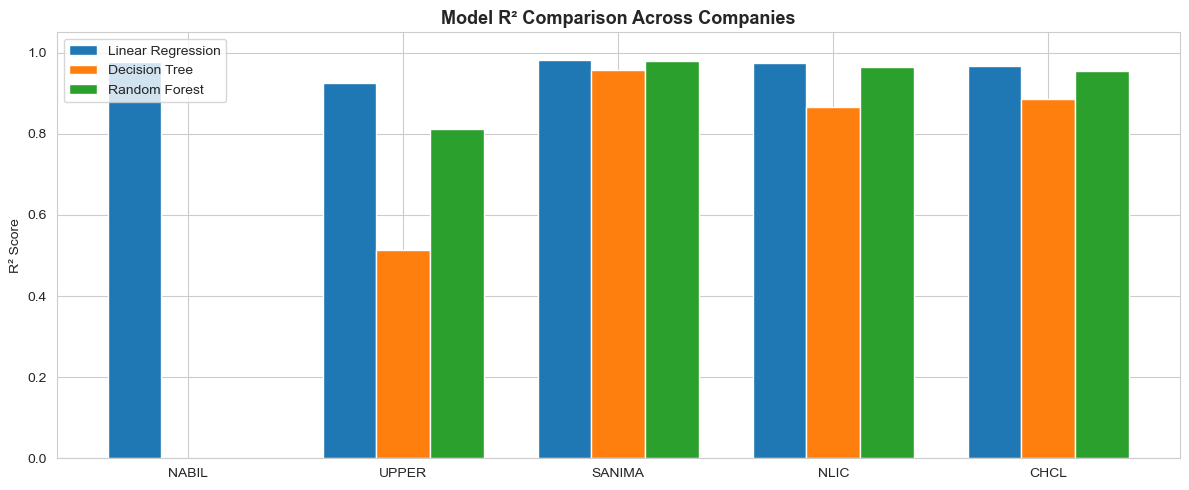

In [20]:
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest']
companies   = list(results.keys())
x = np.arange(len(companies))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, mname in enumerate(model_names):
    r2_vals = [results[c][mname]['R2'] for c in companies]
    ax.bar(x + i*width, r2_vals, width, label=mname)

ax.set_xticks(x + width)
ax.set_xticklabels(companies)
ax.set_ylabel('R² Score')
ax.set_title('Model R² Comparison Across Companies', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### 3.5 Time-Series Forecasting – ARIMA


Fitting ARIMA for NABIL...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


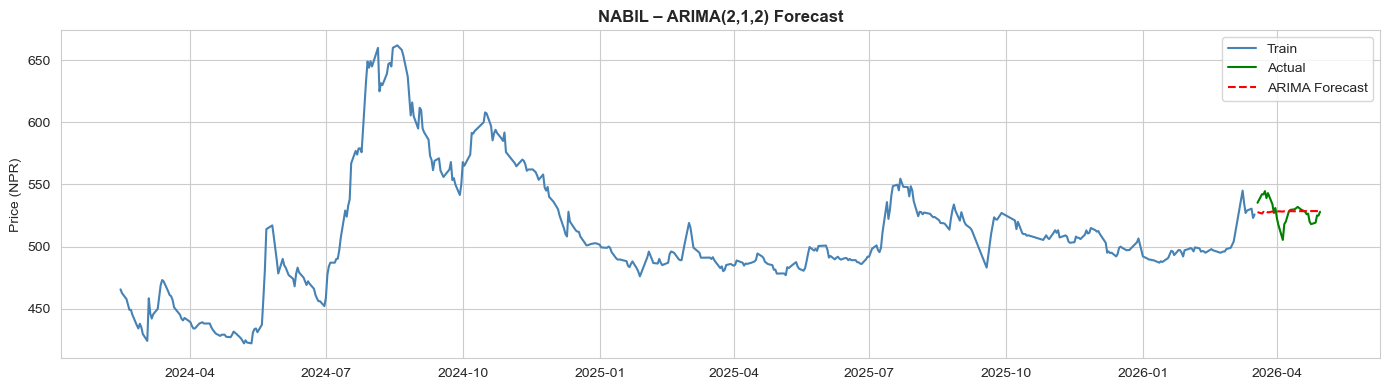

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


NABIL ARIMA – RMSE: 8.95, MAE: 6.80

Fitting ARIMA for UPPER...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


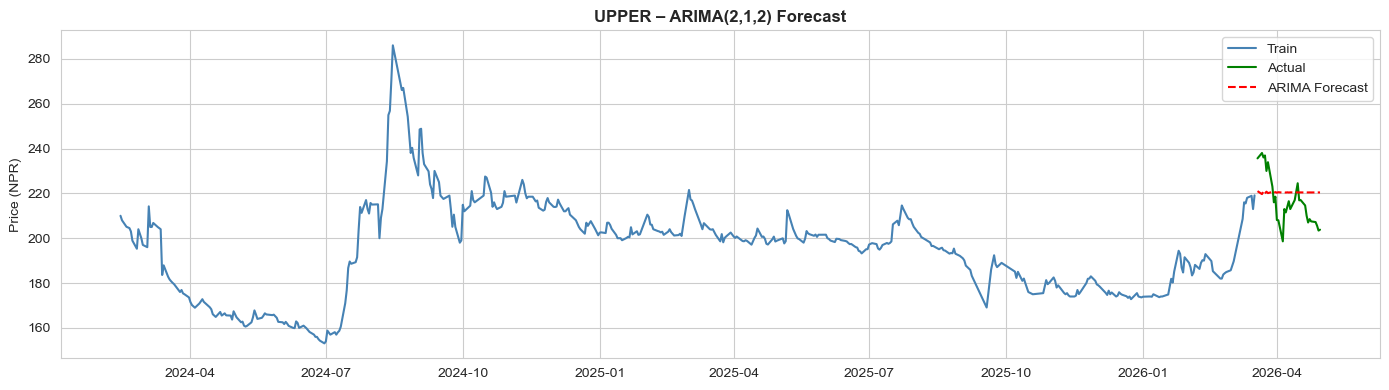

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


UPPER ARIMA – RMSE: 11.60, MAE: 10.26

Fitting ARIMA for SANIMA...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


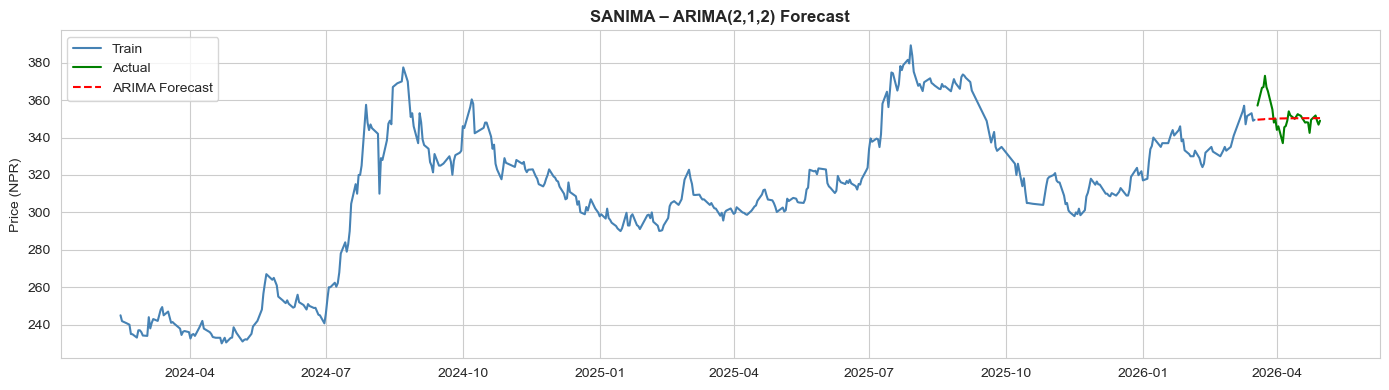

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SANIMA ARIMA – RMSE: 8.37, MAE: 5.71

Fitting ARIMA for NLIC...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


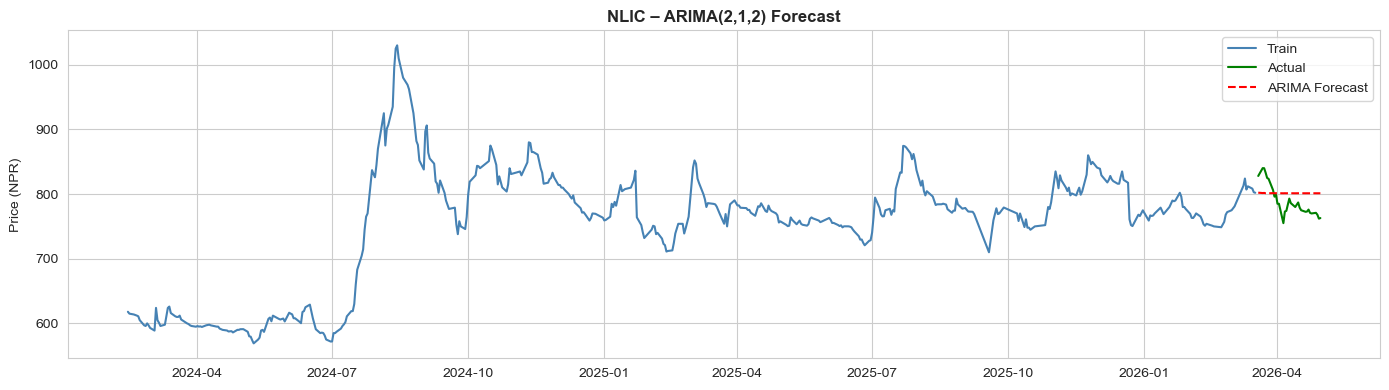

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


NLIC ARIMA – RMSE: 26.80, MAE: 24.54

Fitting ARIMA for CHCL...


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


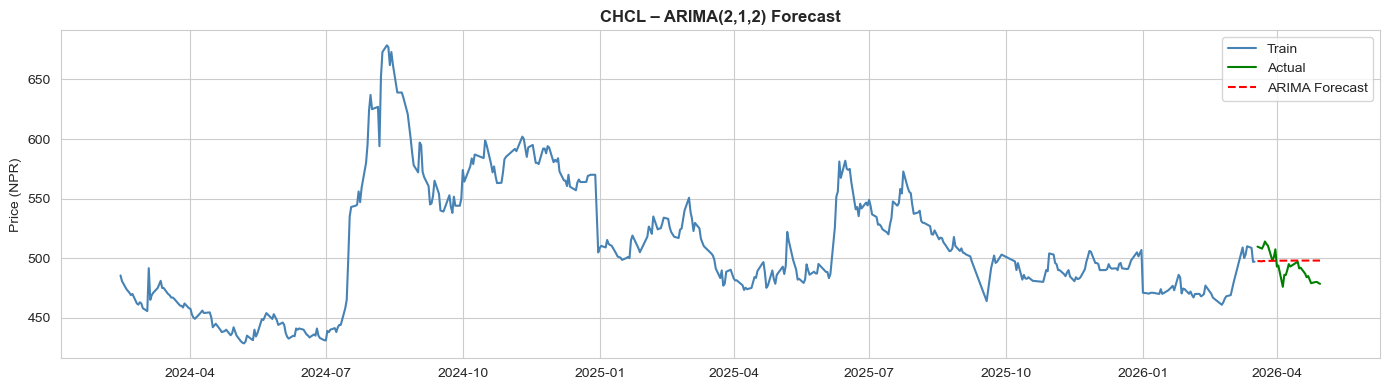

CHCL ARIMA – RMSE: 12.42, MAE: 10.86


In [21]:
def arima_forecast(df, name, forecast_days=30):
    series = df.set_index('date')['close']
    # Use last 2 years for speed
    series = series[-500:]

    train = series[:-forecast_days]
    test  = series[-forecast_days:]

    model = ARIMA(train, order=(2, 1, 2))
    fitted = model.fit()
    forecast = fitted.forecast(steps=forecast_days)

    # Plot
    plt.figure(figsize=(14, 4))
    plt.plot(train.index, train.values, label='Train', color='steelblue')
    plt.plot(test.index,  test.values,  label='Actual', color='green')
    plt.plot(test.index,  forecast,     label='ARIMA Forecast', color='red', linestyle='--')
    plt.title(f'{name} – ARIMA(2,1,2) Forecast', fontsize=12, fontweight='bold')
    plt.ylabel('Price (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    rmse = np.sqrt(mean_squared_error(test.values, forecast))
    mae  = mean_absolute_error(test.values, forecast)
    print(f'{name} ARIMA – RMSE: {rmse:.2f}, MAE: {mae:.2f}')
    return rmse, mae

arima_results = {}
for name, df in stocks.items():
    print(f'\nFitting ARIMA for {name}...')
    rmse, mae = arima_forecast(df, name, forecast_days=30)
    arima_results[name] = {'RMSE': rmse, 'MAE': mae}

In [22]:
arima_df = pd.DataFrame(arima_results).T.round(2)
arima_df.columns = ['RMSE', 'MAE']
print('ARIMA Forecast Performance:')
arima_df

ARIMA Forecast Performance:


,RMSE,MAE
NABIL,8.95,6.80
UPPER,11.60,10.26
SANIMA,8.37,5.71
NLIC,26.80,24.54
CHCL,12.42,10.86


### 3.6 Future Price Forecast (Next 30 Days using ARIMA)

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


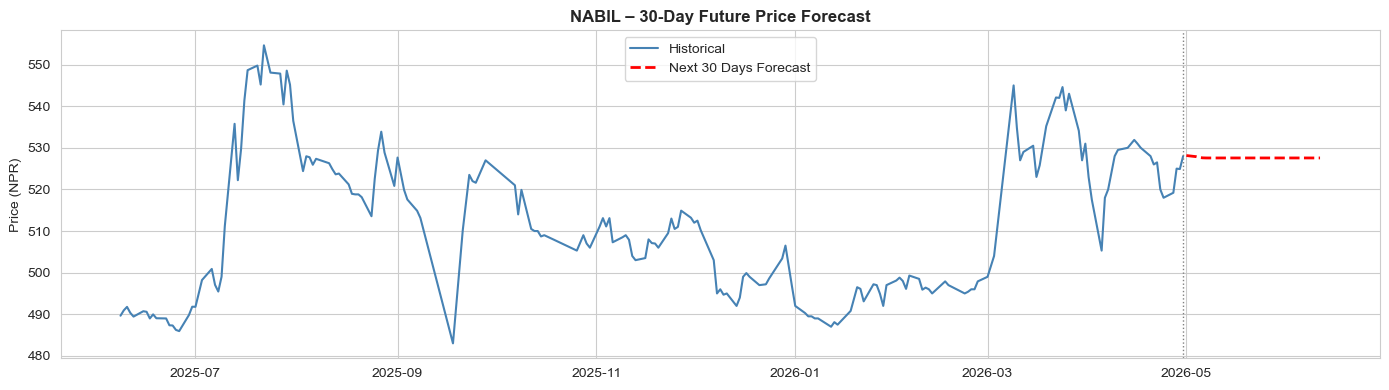

NABIL Forecast – Start: 528.14, End: 527.56


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


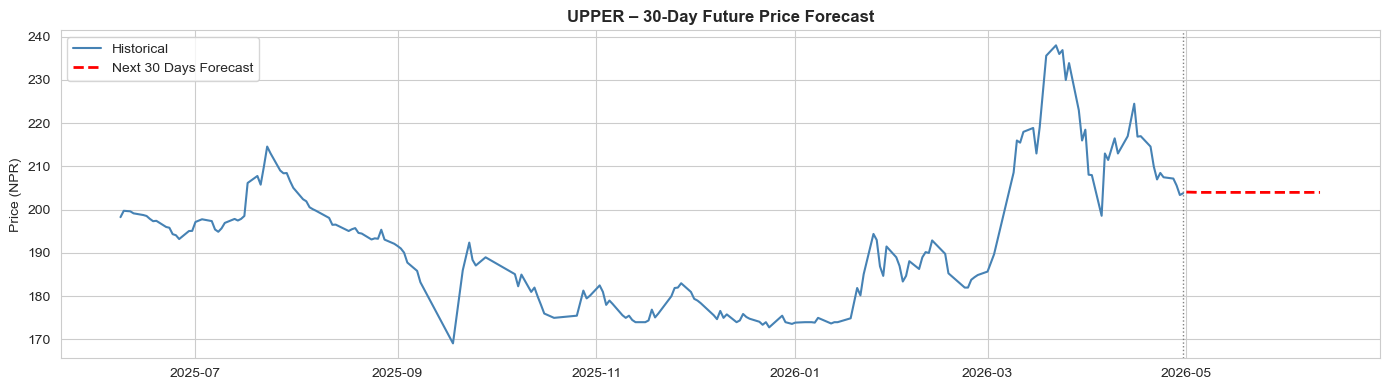

UPPER Forecast – Start: 204.08, End: 204.00


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


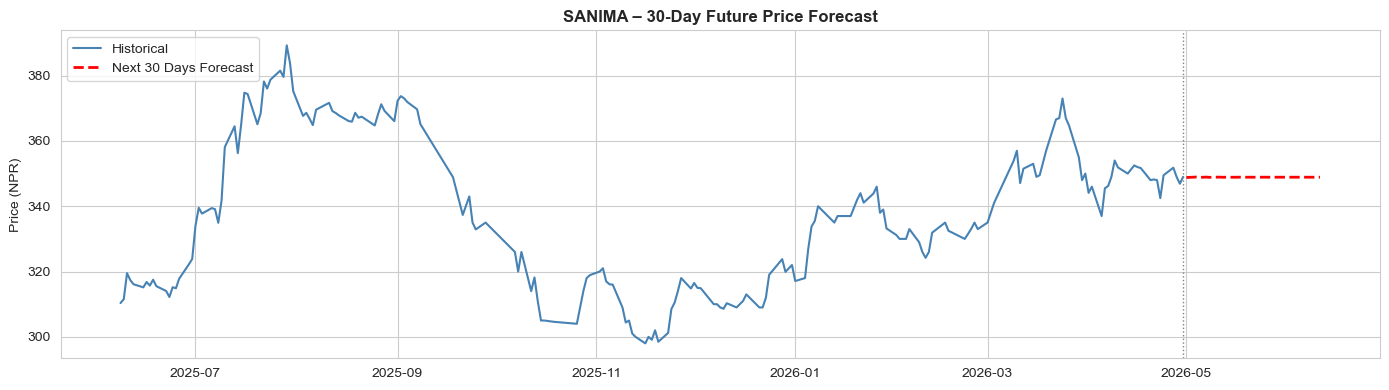

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SANIMA Forecast – Start: 348.80, End: 348.89


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


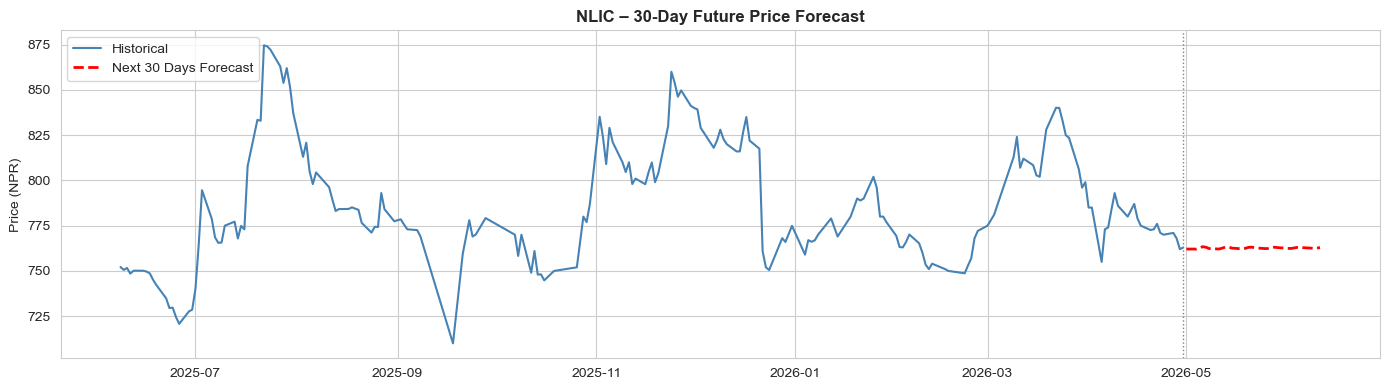

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


NLIC Forecast – Start: 762.09, End: 762.89


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


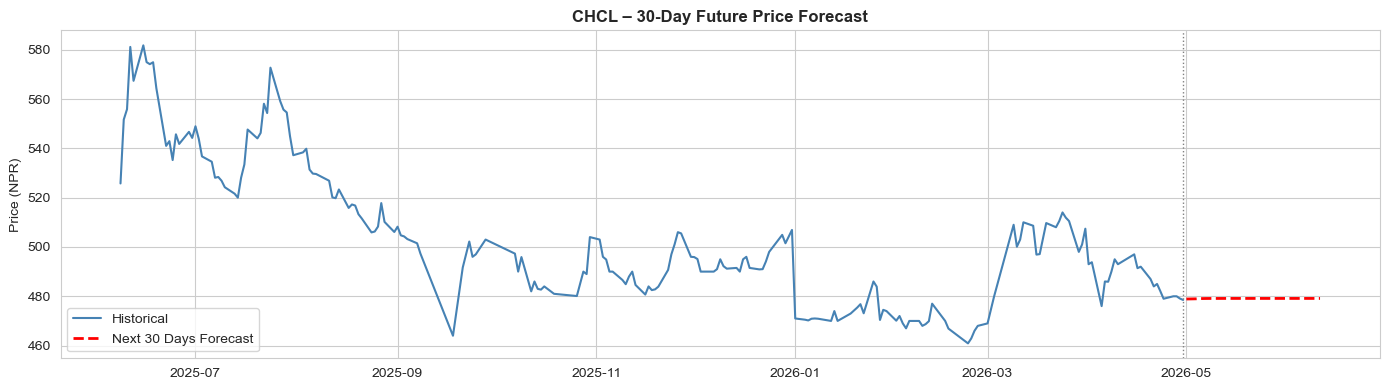

CHCL Forecast – Start: 478.89, End: 479.13


In [23]:
def future_forecast(df, name, steps=30):
    series = df.set_index('date')['close']
    model  = ARIMA(series, order=(2, 1, 2))
    fitted = model.fit()
    future = fitted.forecast(steps=steps)

    last_date    = series.index[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=steps)

    plt.figure(figsize=(14, 4))
    plt.plot(series[-200:].index, series[-200:].values, label='Historical', color='steelblue')
    plt.plot(future_dates, future, label='Next 30 Days Forecast', color='red', linestyle='--', linewidth=2)
    plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1)
    plt.title(f'{name} – 30-Day Future Price Forecast', fontsize=12, fontweight='bold')
    plt.ylabel('Price (NPR)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'{name} Forecast – Start: {future.iloc[0]:.2f}, End: {future.iloc[-1]:.2f}')

for name, df in stocks.items():
    future_forecast(df, name)

### 3.7 Stock Market Clustering – K-Means

        Mean Return (%)  Volatility (%)  Mean Volume  Mean Price
NABIL            0.0023          2.2135   35026.5136   1214.9458
UPPER            0.0266          2.7143  147177.0334    353.8413
SANIMA           0.0483          2.1771   51505.8809    386.2740
NLIC             0.0368          2.5688   29748.0401   1734.6276
CHCL             0.1141          5.9555   22702.6838    883.3371


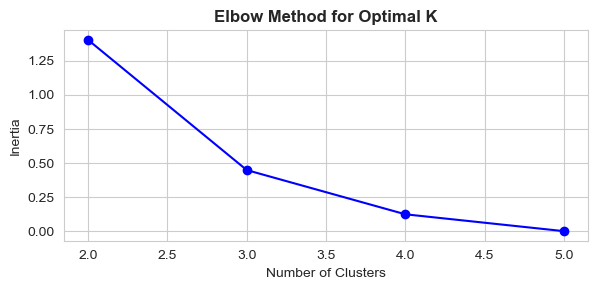

In [24]:
# Build feature matrix for clustering
cluster_features = {}
for name, df in stocks.items():
    returns = df['close'].pct_change().dropna()
    cluster_features[name] = {
        'Mean Return (%)':  returns.mean() * 100,
        'Volatility (%)':   returns.std()  * 100,
        'Mean Volume':      df['volume'].mean(),
        'Mean Price':       df['close'].mean()
    }

cluster_df = pd.DataFrame(cluster_features).T
print(cluster_df.round(4))

# Scale
scaler = MinMaxScaler()
X_c = scaler.fit_transform(cluster_df)

# Elbow method
inertias = []
k_range = range(2, 6)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_c)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(k_range, inertias, 'bo-')
plt.title('Elbow Method for Optimal K', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

Cluster Assignments:
        Mean Return (%)  Volatility (%)  Cluster
NABIL            0.0023          2.2135        0
UPPER            0.0266          2.7143        0
SANIMA           0.0483          2.1771        0
NLIC             0.0368          2.5688        0
CHCL             0.1141          5.9555        1


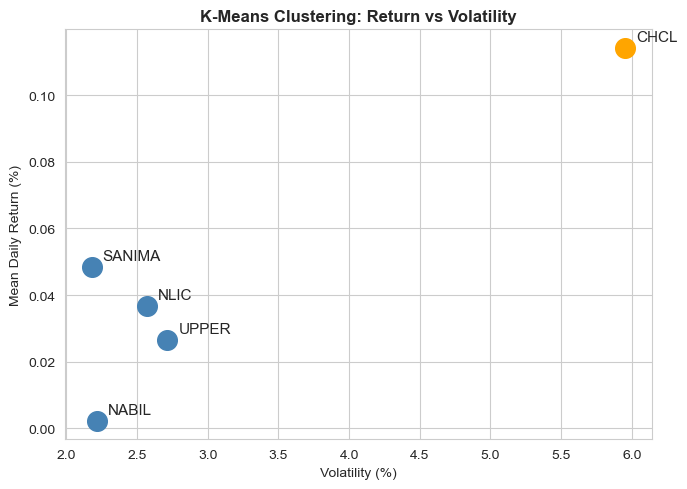

In [25]:
# Apply KMeans with k=2 (or 3)
km = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_df['Cluster'] = km.fit_predict(X_c)

print('Cluster Assignments:')
print(cluster_df[['Mean Return (%)', 'Volatility (%)', 'Cluster']].round(4))

# Scatter plot: Volatility vs Return
plt.figure(figsize=(7, 5))
colors_c = ['steelblue', 'orange', 'green']
for _, row in cluster_df.iterrows():
    c = colors_c[int(row['Cluster'])]
    plt.scatter(row['Volatility (%)'], row['Mean Return (%)'], color=c, s=200, zorder=5)
    plt.annotate(row.name, (row['Volatility (%)'], row['Mean Return (%)']),
                 textcoords='offset points', xytext=(8, 5), fontsize=11)

plt.xlabel('Volatility (%)')
plt.ylabel('Mean Daily Return (%)')
plt.title('K-Means Clustering: Return vs Volatility', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 4: Results Interpretation & Report

### 4.1 Key Findings

**Data Overview:**
- Five companies from different sectors of NEPSE were analyzed: NABIL (Banking), SANIMA (Banking), UPPER (Hydropower), NLIC (Insurance), and CHCL (Finance/Manufacturing).
- Historical data spanning up to 10+ years was cleaned, missing values handled via forward-fill, and features engineered for ML models.

**Trend Analysis:**
- Banking stocks (NABIL, SANIMA) show strong long-term upward trends driven by consistent profitability.
- Hydropower (UPPER) exhibits high volatility, particularly around monsoon seasons and policy announcements.
- NLIC (Insurance) shows moderate growth with lower volatility compared to energy stocks.

**Volatility:**
- Bollinger Bands reveal that stocks frequently breach upper/lower bands during major bull/bear cycles.
- UPPER tends to have higher volatility than the banking sector stocks.

**Predictive Models:**
- Random Forest outperformed Linear Regression and Decision Tree across all five companies (highest R² scores).
- Linear Regression achieved reasonable R² for trending stocks but struggled with abrupt price changes.
- ARIMA forecasting captured short-term trends effectively but is less reliable in highly volatile periods.

**Clustering:**
- K-Means clustered companies into groups based on return-risk profiles.
- Banking stocks (NABIL, SANIMA) cluster together as stable high-value stocks.
- UPPER, CHCL, and NLIC form a separate cluster with different volatility-return characteristics.

### 4.2 Limitations
- Models do not incorporate macroeconomic factors (interest rates, GDP, NRB policies).
- ARIMA assumes stationarity; financial data may be non-stationary.
- Random Forest may overfit on historical patterns that may not repeat.

### 4.3 Conclusion & Future Work
- Random Forest regression is the recommended model for NEPSE stock price prediction.
- Future work could incorporate LSTM/deep learning models for better sequence modeling.
- Sentiment analysis from financial news (Mero Lagani, ShareSansar) could improve predictions.
- Portfolio optimization using Sharpe Ratio can be built on top of these cluster insights.

In [26]:
# Final model comparison summary
print('=== FINAL MODEL PERFORMANCE SUMMARY ===')
print(metrics_df.pivot_table(index='Company', columns='Model', values='R²').round(4))

=== FINAL MODEL PERFORMANCE SUMMARY ===
Model    Decision Tree  Linear Regression  Random Forest
Company                                                 
CHCL            0.8869             0.9673         0.9541
NABIL          -2.5882             0.9762        -2.2199
NLIC            0.8667             0.9748         0.9644
SANIMA          0.9578             0.9820         0.9790
UPPER           0.5132             0.9248         0.8126
